#TelecomX - Parte 2

##🛠️ Preparación de los Datos

###Extracción del Archivo Tratado

In [126]:
import pandas as pd

In [127]:
#mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [128]:
#Leer csv
datos = pd.read_csv('/content/datos_procesados.csv')
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,0,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,1,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [129]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   int64  
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   int64  
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   int64  
 11  OnlineBackup      7043 non-null   int64  
 12  DeviceProtection  7043 non-null   int64  
 13  TechSupport       7043 non-null   int64  
 14  StreamingTV       7043 non-null   int64  
 15  StreamingMovies   7043 non-null   int64  
 16  Contract          7043 non-null   object 


###Verificación de la Proporción de Cancelación (Churn)

In [130]:
datos['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0,73.463013
1,26.536987


Existe un **desbalance**  entre las clases

###Análisis Dirigido

####Densidad de churn por variables numericas

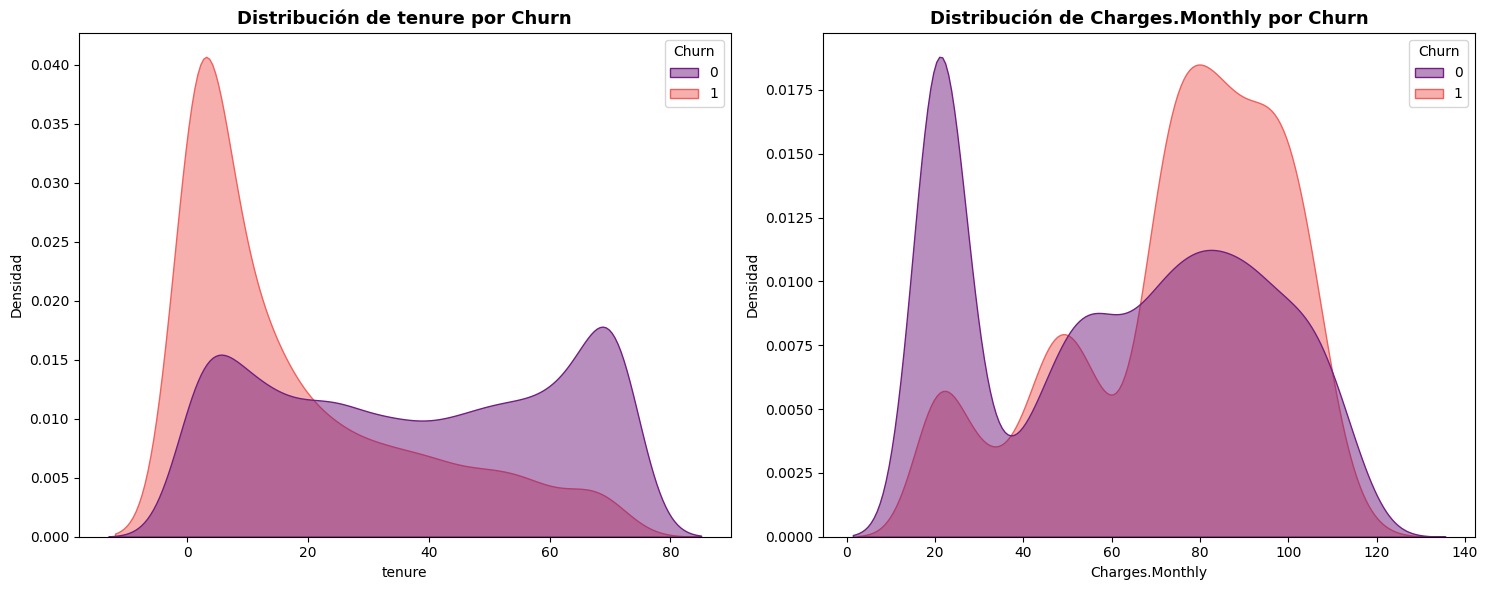

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_densidad_churn(df, variables_numericas):
    n_vars = len(variables_numericas)
    fig, axes = plt.subplots(1, n_vars, figsize=(15, 6))

    for i, col in enumerate(variables_numericas):
        sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False,
                    palette='magma', alpha=0.5, ax=axes[i])
        axes[i].set_title(f'Distribución de {col} por Churn', fontsize=13, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Densidad')

    plt.tight_layout()
    plt.show()

# Ejecución para el dataframe original
graficar_densidad_churn(datos, ['tenure', 'Charges.Monthly'])

####Tasa de churn por variables categoricas

In [132]:
def visualizar_tasas_churn(df, target='Churn'):
    # Seleccionamos columnas que no sean numéricas continuas (floats)
    # o que tengan pocos valores únicos (como Total_Tech_Services)
    columnas_interes = [col for col in df.columns if df[col].nunique() < 10 and col != target]

    # Configuramos la cuadrícula de gráficos
    n_cols = 2
    n_rows = (len(columnas_interes) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(columnas_interes):
        # 1. Creamos la tabla de frecuencias normalizada (proporciones)
        tabla_prop = pd.crosstab(df[col], df[target], normalize='index') * 100

        # 2. Graficamos
        tabla_prop.plot(kind='bar',
                        stacked=True,
                        ax=axes[i],
                        color=['#2ecc71', '#e74c3c'], # Verde: se queda, Rojo: se va
                        alpha=0.8)

        axes[i].set_title(f'Tasa de Churn por: {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Porcentaje (%)')
        axes[i].set_xlabel('')
        axes[i].legend(title='Churn', labels=['Queda (0)', 'Fuga (1)'], loc='upper right')

        # Añadir etiquetas de porcentaje dentro de las barras
        for p in axes[i].patches:
            width, height = p.get_width(), p.get_height()
            x, y = p.get_xy()
            if height > 5: # Solo mostrar si el segmento es visible
                axes[i].text(x + width/2,
                             y + height/2,
                             f'{height:.1f}%',
                             horizontalalignment='center',
                             verticalalignment='center',
                             color='white',
                             fontweight='bold')

    # Eliminar ejes sobrantes si el número de columnas es impar
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

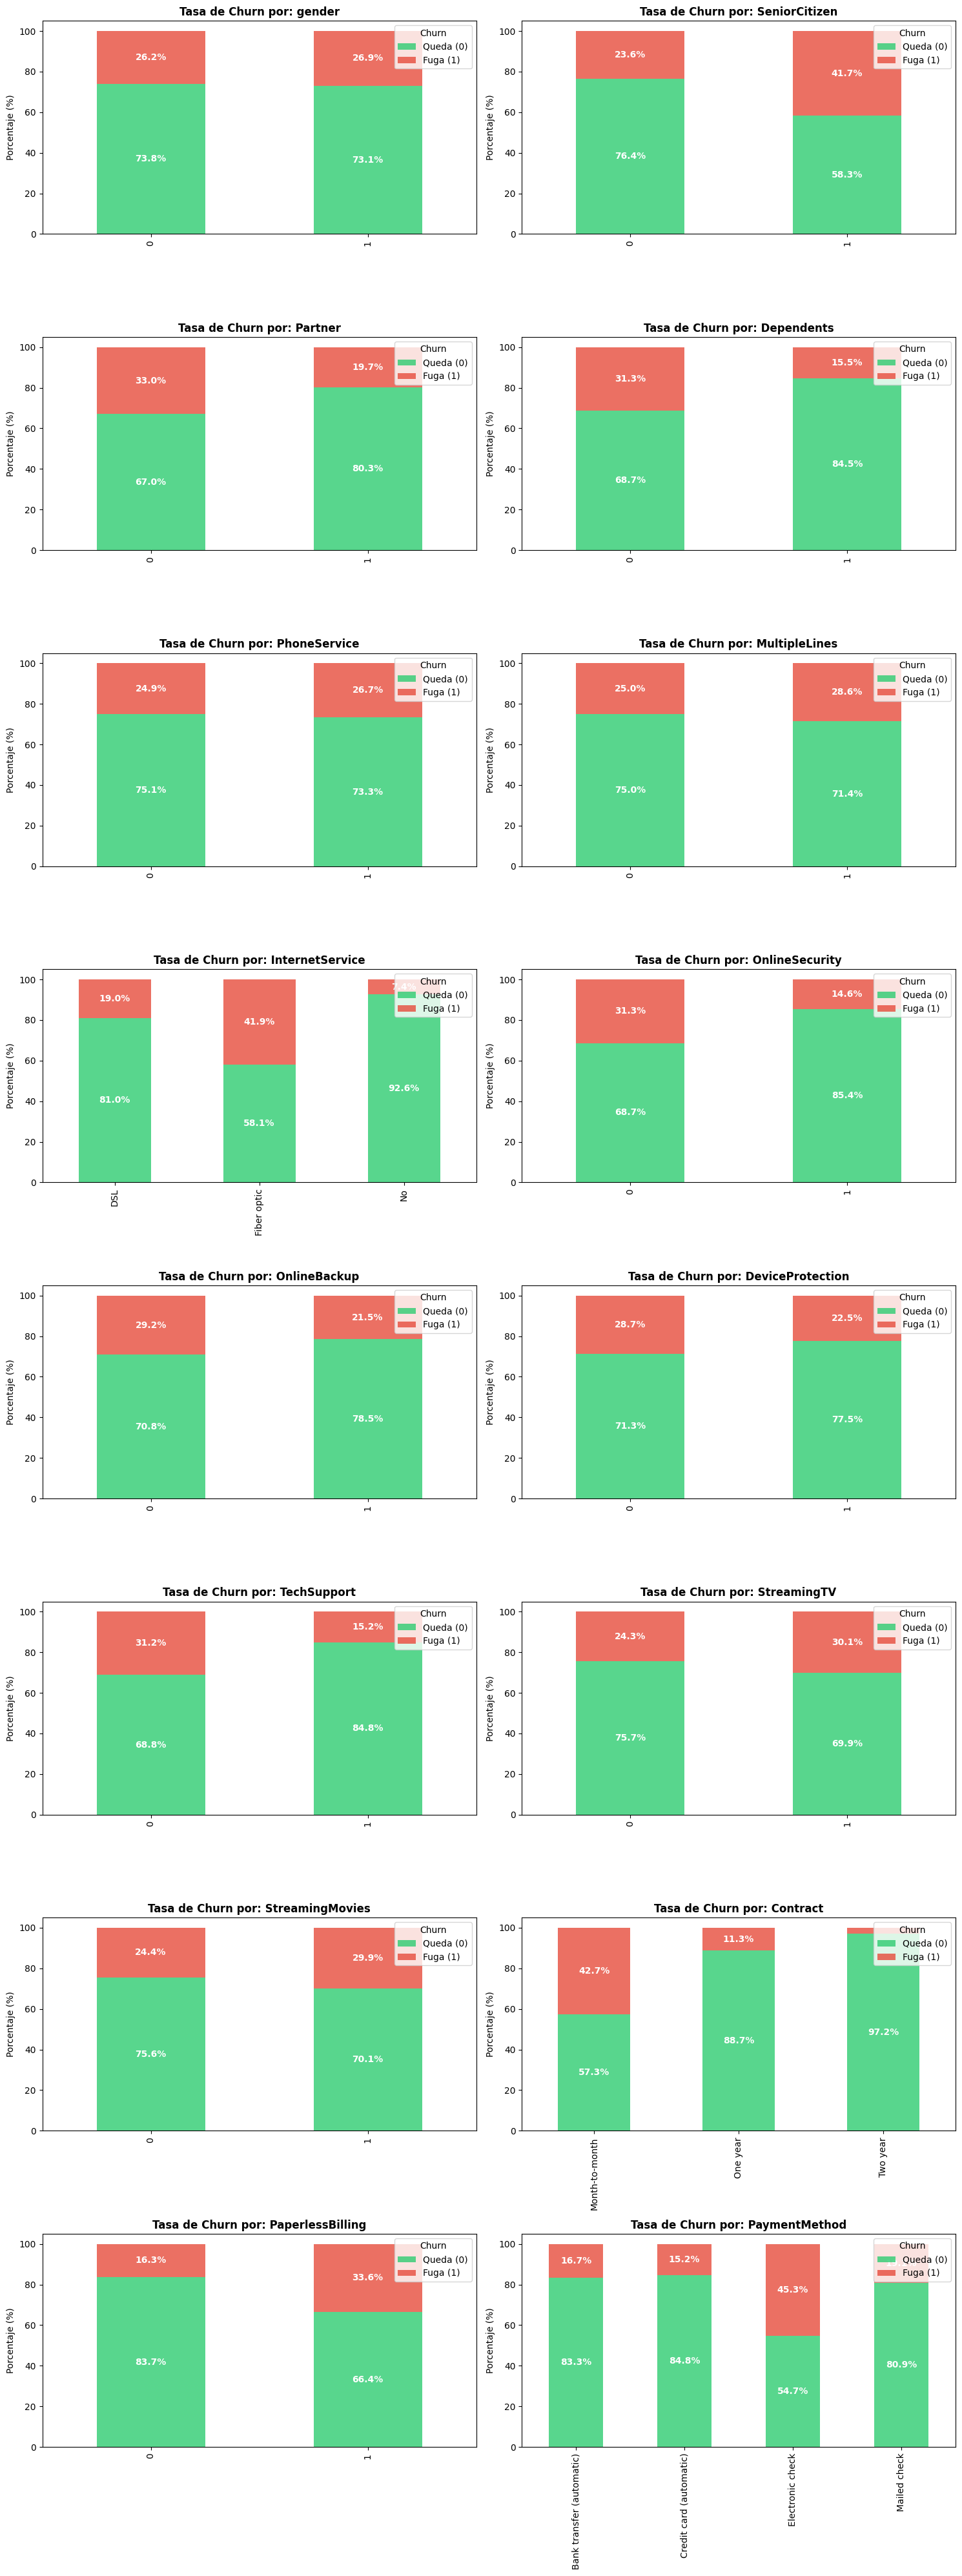

In [133]:
visualizar_tasas_churn(datos)

###Feature Engineering

In [134]:
datos.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Charges.Daily'],
      dtype='object')

####Borrar Identificador

In [135]:
#Borrar ID
datos = datos.drop('customerID', axis=1)
datos.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Charges.Daily'],
      dtype='object')

####Guardamos el df original

In [136]:
# Copia del df original
df_original = datos.copy()

####Creamos copia para experimentar

In [137]:
# Versión B para aplicar Feature Engineering
df_ingenieria = datos.copy()

####Verificar existencia de columnas con varianza 0

In [138]:
def verificar_varianza(df, umbral_dominancia=0.95):
    """
    Identifica columnas con un solo valor o donde un valor
    es extremadamente dominante.
    """
    columnas_inservibles = []
    resumen = []

    for col in df.columns:
        # 1. Calculamos la frecuencia relativa del valor más común
        frecuencias = df[col].value_counts(normalize=True)

        if len(frecuencias) > 0:
            top_valor_pct = frecuencias.iloc[0] # % del valor más frecuente
            n_unicos = len(frecuencias)         # Cantidad de valores distintos

            # 2. Si solo hay 1 valor (Varianza Cero)
            if n_unicos == 1:
                columnas_inservibles.append(col)
                resumen.append({'Columna': col, 'Motivo': 'Varianza Cero', 'Detalle': '1 único valor'})

            # 3. Si un valor domina casi toda la columna (Varianza Casi Cero)
            elif top_valor_pct >= umbral_dominancia:
                columnas_inservibles.append(col)
                resumen.append({'Columna': col, 'Motivo': 'Casi Cero', 'Detalle': f'{round(top_valor_pct*100, 2)}% dominante'})

    # Mostramos reporte
    if resumen:
        print("🔍 Columnas identificadas para eliminación:")
        return pd.DataFrame(resumen)
    else:
        print("✅ ¡Todas las columnas tienen varianza útil!")
        return None

In [139]:
reporte_bajas = verificar_varianza(datos)

✅ ¡Todas las columnas tienen varianza útil!


####Identificar multicolinealidad

In [140]:
datos.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Charges.Daily'],
      dtype='object')

In [141]:
import numpy as np

def graficar_y_guardar_correlacion(df, nombre_archivo="matriz_correlacion.png"):
    # Calculamos correlación
    corr = df.select_dtypes(include=[np.number]).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)

    plt.title("Matriz de Correlación")

    # --- LA PARTE IMPORTANTE ---
    # Guardamos antes de plt.show() porque show() "limpia" el lienzo
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')

    plt.show()
    print(f"✅ Gráfico guardado como: {nombre_archivo}")

# Ejemplo de uso:
# graficar_y_guardar_correlacion(datos, "correlacion_churn.png")

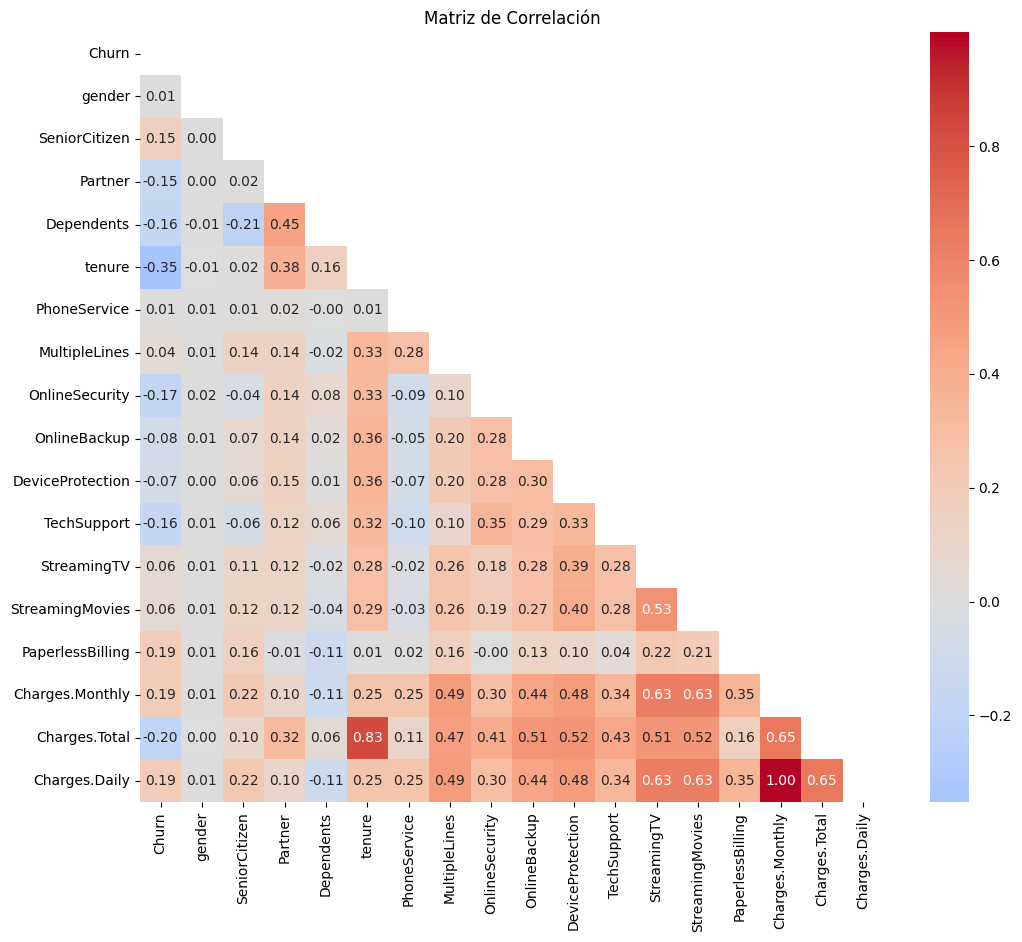

✅ Gráfico guardado como: correlacion_churn.png


In [142]:
graficar_y_guardar_correlacion(datos, "correlacion_churn.png")

####Feature Engineering aplicado a df_ingenieria

In [143]:
# 1. Definir las familias
cols_tech = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
cols_streaming = ['StreamingTV', 'StreamingMovies']

# 2. Crear las variables agregadas
df_ingenieria['Total_Tech_Services'] = df_ingenieria[cols_tech].sum(axis=1)
df_ingenieria['Total_Streaming_Services'] = df_ingenieria[cols_streaming].sum(axis=1)

# 3. Eliminar las originales y las redundantes
drop_cols = cols_tech + cols_streaming + ['gender', 'PhoneService', 'Charges.Daily', 'Charges.Total']

# Ejecutamos el borrado definitivo (sobrescribiendo la variable)
df_ingenieria = df_ingenieria.drop(columns=drop_cols, errors='ignore')

# 4. VERIFICACIÓN FINAL
print(f"Dimensiones finales: {df_ingenieria.shape}")
print(f"Columnas restantes:\n{df_ingenieria.columns.tolist()}")

Dimensiones finales: (7043, 13)
Columnas restantes:
['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Total_Tech_Services', 'Total_Streaming_Services']


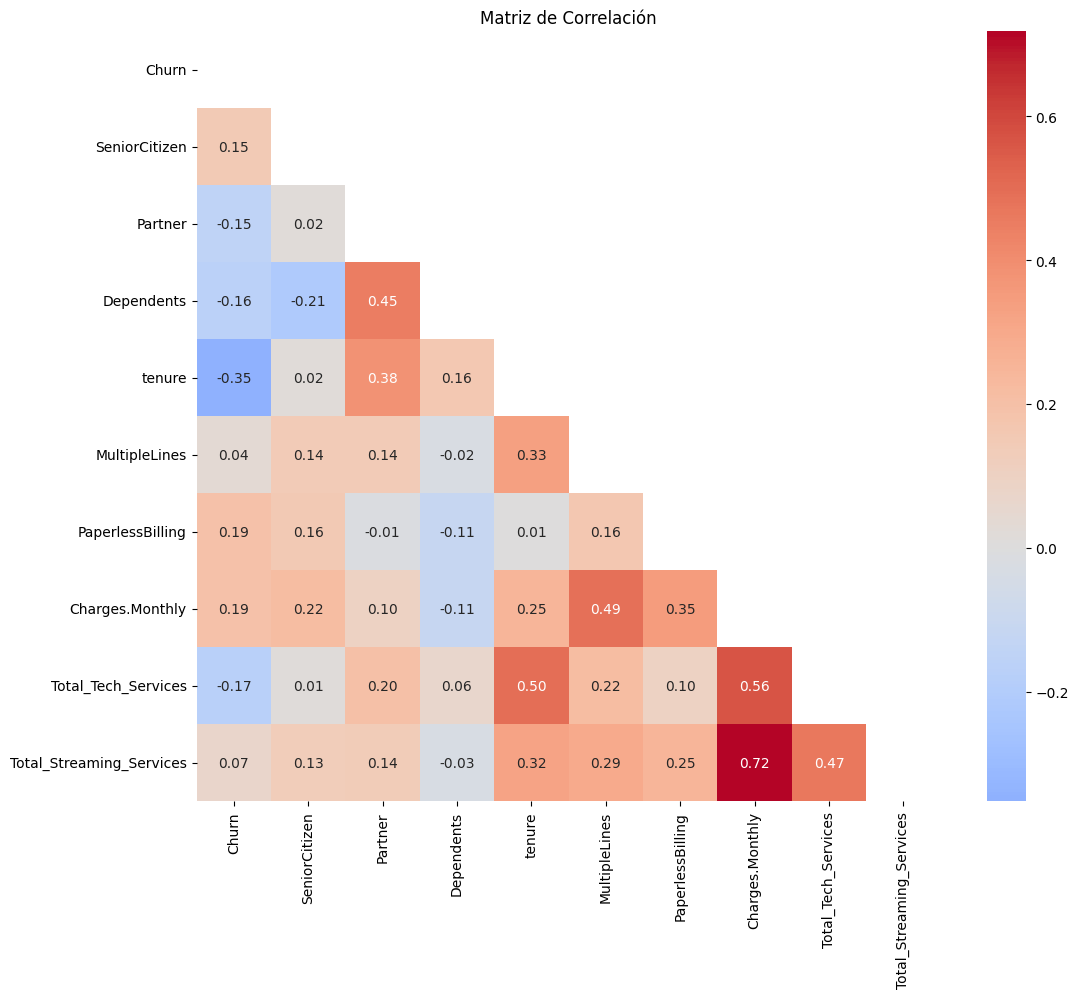

✅ Gráfico guardado como: correlacion_churn_2.png


In [144]:
graficar_y_guardar_correlacion(df_ingenieria, "correlacion_churn_2.png")

####Validación de las Nuevas Variables

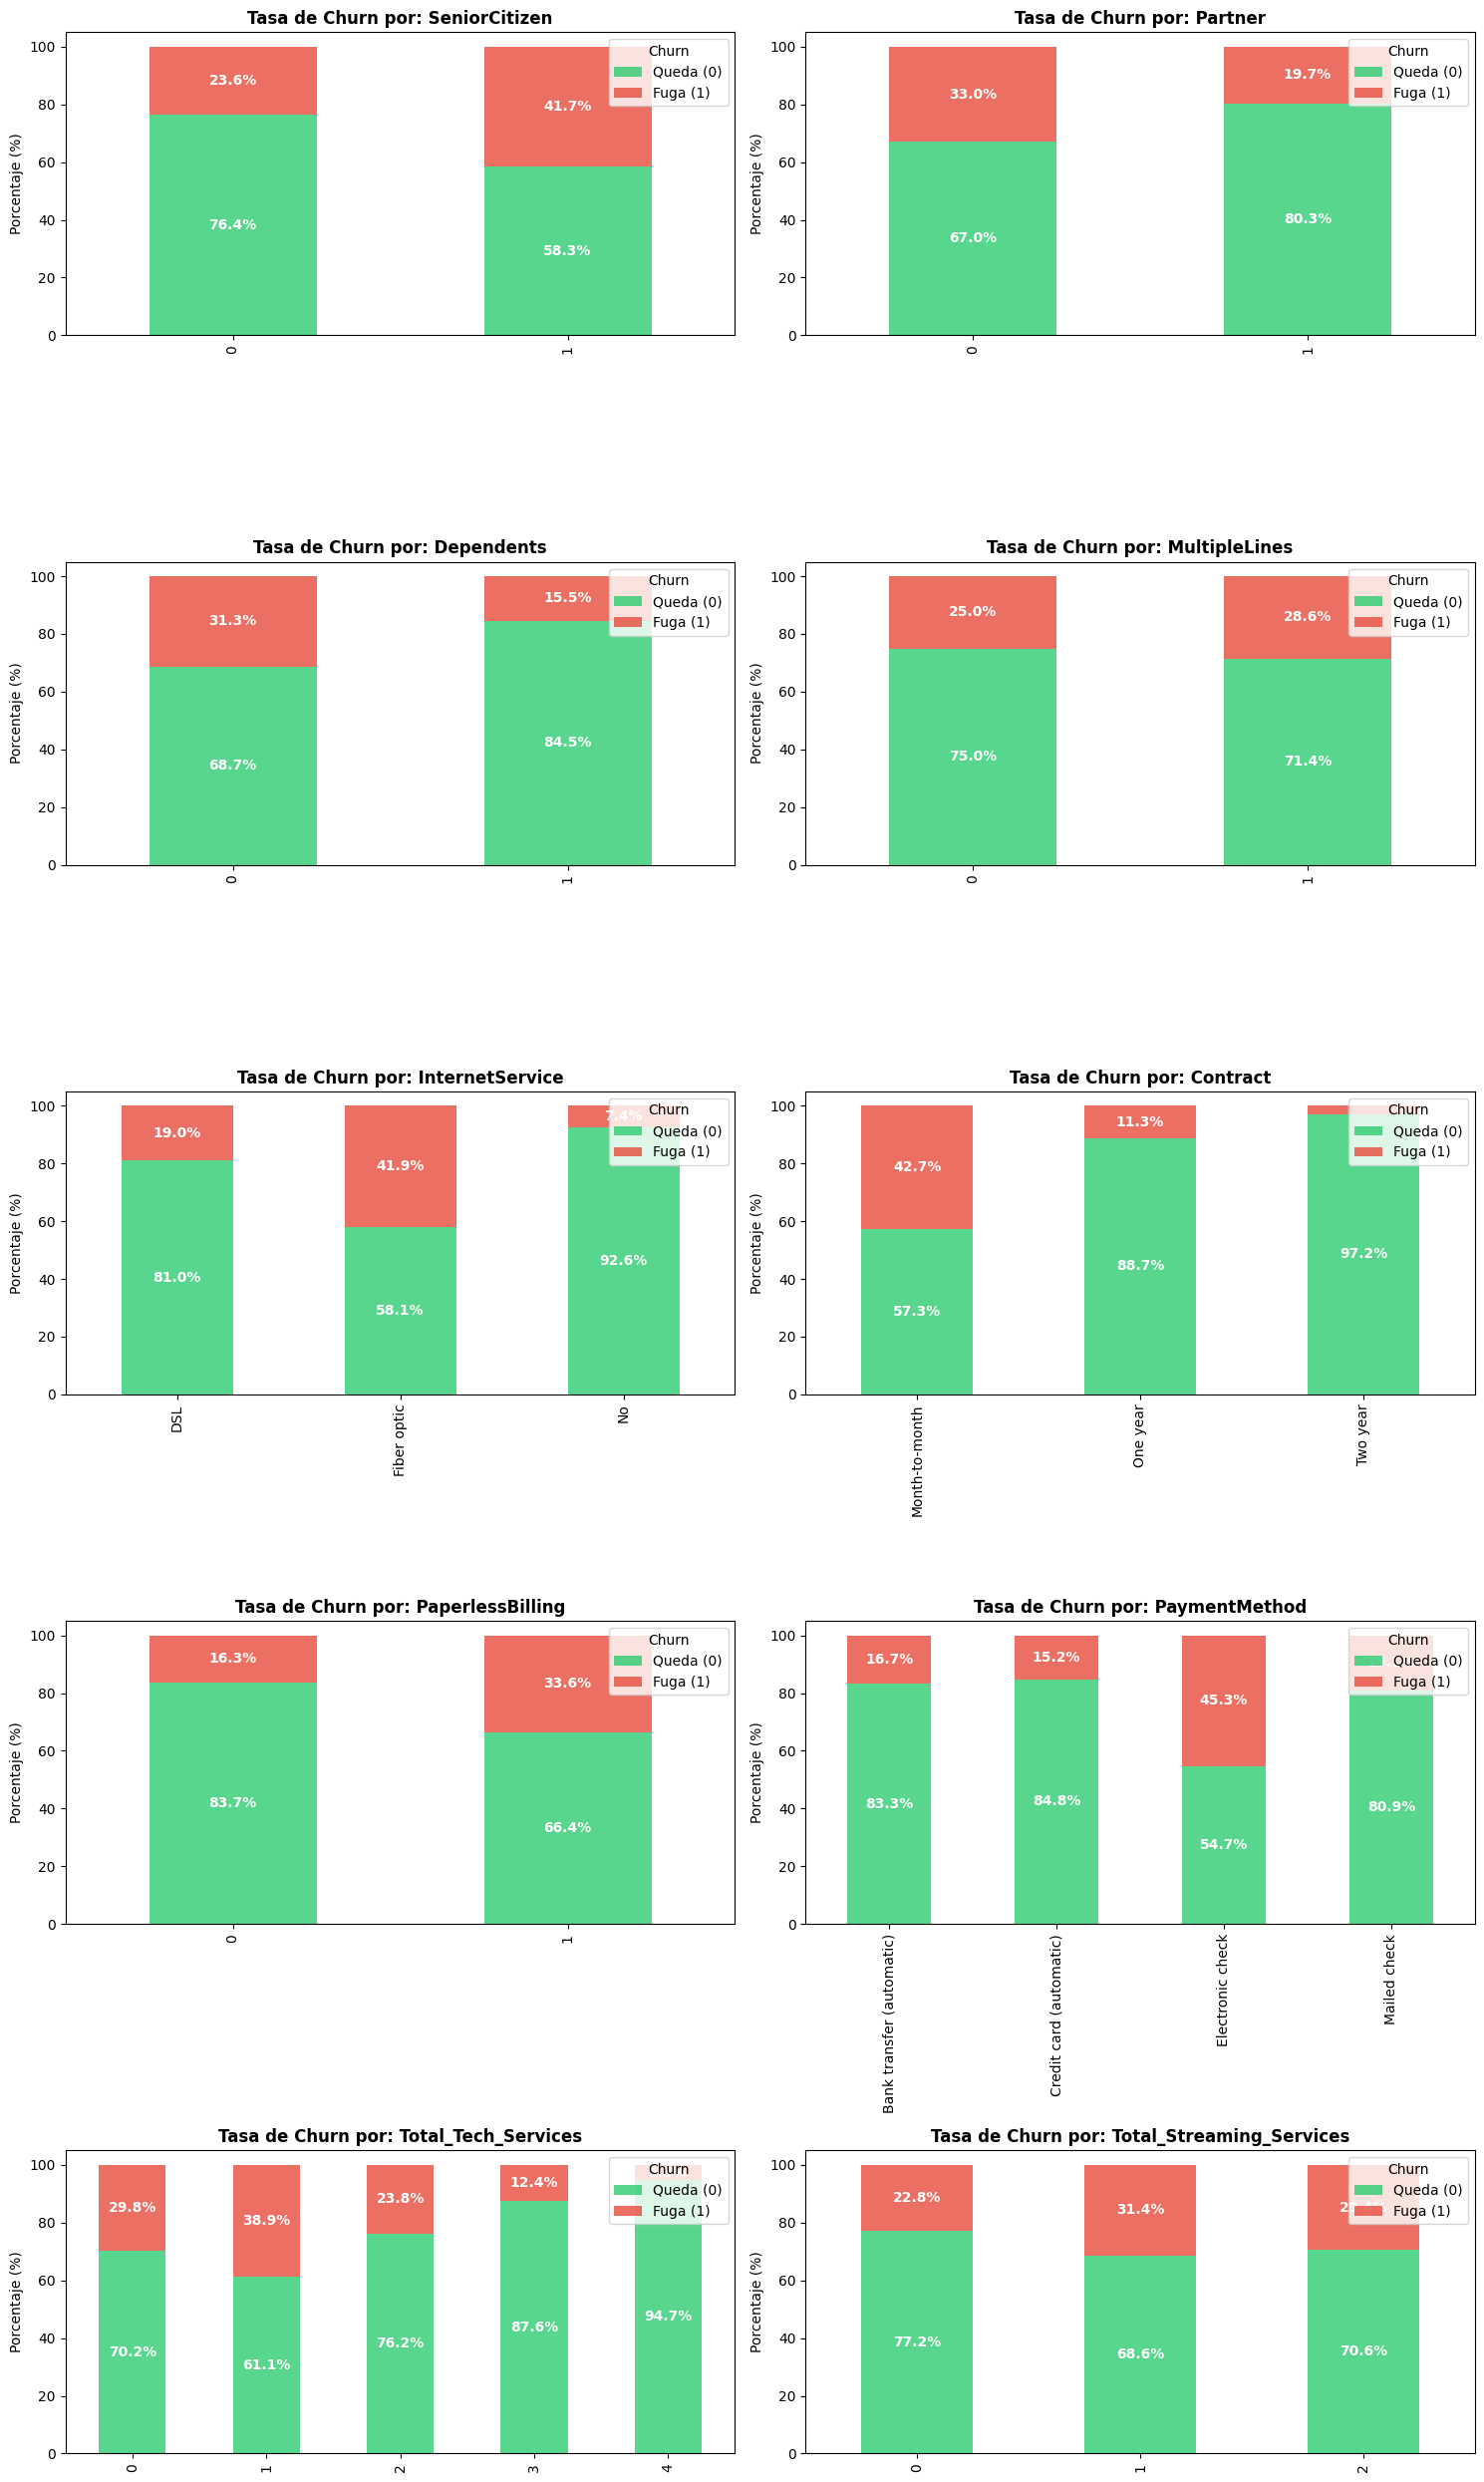

In [145]:
visualizar_tasas_churn(df_ingenieria)

Comparacion visual rapida de los df:

In [146]:
df_original.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0,1,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0,0,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,0,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,0,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,1,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [147]:
df_ingenieria.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Total_Tech_Services,Total_Streaming_Services
0,0,0,1,1,9,0,DSL,One year,1,Mailed check,65.6,2,1
1,0,0,0,0,9,1,DSL,Month-to-month,0,Mailed check,59.9,0,1
2,1,0,0,0,4,0,Fiber optic,Month-to-month,1,Electronic check,73.9,1,0
3,1,1,1,0,13,0,Fiber optic,Month-to-month,1,Electronic check,98.0,2,2
4,1,1,1,0,3,0,Fiber optic,Month-to-month,1,Mailed check,83.9,1,1


###Creacion de Modelos

####Preprocesamiento de datos

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

In [149]:
datos.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0,1,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0,0,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,0,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,0,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,1,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [150]:
def preparar_datos_base(df, target='Churn'):
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 1. Lista de TODAS las posibles variables categóricas
    nominales_potenciales = ['InternetService', 'Contract', 'PaymentMethod']
    # Filtro: Solo usamos las que realmente existan en el DataFrame actual
    nominales = [c for c in nominales_potenciales if c in X.columns]

    # 2. Lista de TODAS las posibles variables numéricas (base + ingeniería)
    numericas_potenciales = [
        'tenure', 'Charges.Monthly', 'Charges.Total', 'Charges.Daily',
        'Total_Tech_Services', 'Total_Streaming_Services'
    ]
    # Filtro: Solo usamos las que realmente existan en el DataFrame actual
    numericas = [c for c in numericas_potenciales if c in X.columns]

    return X_train, X_test, y_train, y_test, nominales, numericas

###Evaluacion de configuracion (df_original y df_ingenieria)

In [151]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [152]:
def evaluar_configuracion(df, nombre_df):
    # 1. Preparar datos y listas
    X_train, X_test, y_train, y_test, nominales, numericas = preparar_datos_base(df)

    # 2. Configurar Preprocesadores
    # Para RF: Solo OneHot, numéricas pasan crudas
    pre_rf = make_column_transformer(
        (OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominales),
        remainder='passthrough'
    )

    # Para LR: OneHot + StandardScaler
    pre_lr = make_column_transformer(
        (OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominales),
        (StandardScaler(), numericas),
        remainder='passthrough'
    )

    # 3. Definir Pipelines
    pipe_rf = Pipeline([
        ('pre', pre_rf),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42, max_depth=10))
    ])

    pipe_lr = Pipeline([
        ('pre', pre_lr),
        ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=5000))
    ])

    # 4. Validación Cruzada (F1-Score)
    score_rf = cross_val_score(pipe_rf, X_train, y_train, cv=5, scoring='f1').mean()
    score_lr = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring='f1').mean()

    return {
        'Dataset': nombre_df,
        'F1 Random Forest': round(score_rf, 4),
        'F1 Regresión Logística': round(score_lr, 4)
    }

# --- Lanzamos la comparativa ---
resultados = []
resultados.append(evaluar_configuracion(df_original, "Original"))
resultados.append(evaluar_configuracion(df_ingenieria, "Ingeniería"))

# Presentamos los resultados en una tabla limpia
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

      Dataset  F1 Random Forest  F1 Regresión Logística
0    Original            0.6351                  0.6268
1  Ingeniería            0.6317                  0.6274


####Comparacion de Metricas

In [153]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluar_modelo_final(modelo, X_test, y_test, nombre_modelo):
    """
    Toma un modelo entrenado, predice sobre el set de prueba y calcula todas las métricas requeridas.
    """
    # 1. El modelo hace sus predicciones
    y_pred = modelo.predict(X_test)

    # 2. Calculamos las métricas matemáticas
    exactitud = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # 3. Imprimimos el reporte formal
    print(f"📊 RESULTADOS DEL MODELO: {nombre_modelo.upper()} 📊")
    print("-" * 45)
    print(f"Exactitud (Accuracy) : {exactitud:.4f} -> (% de aciertos totales)")
    print(f"Precisión (Precision): {precision:.4f} -> (De los que dijimos que se van, ¿cuántos realmente se fueron?)")
    print(f"Recall (Sensibilidad): {recall:.4f} -> (De todos los que se fueron, ¿a cuántos logramos detectar?)")
    print(f"F1-Score             : {f1:.4f} -> (El equilibrio entre Precisión y Recall)")
    print("-" * 45 + "\n")

    # 4. Generamos la Matriz de Confusión visual
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Se Queda (0)', 'Se Va (1)']
    )

    # Dibujamos el gráfico
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title(f'Matriz de Confusión: {nombre_modelo}', fontsize=14, pad=15)
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Realidad del Cliente')
    plt.show()

📊 RESULTADOS DEL MODELO: RANDOM FOREST 📊
---------------------------------------------
Exactitud (Accuracy) : 0.7764 -> (% de aciertos totales)
Precisión (Precision): 0.5616 -> (De los que dijimos que se van, ¿cuántos realmente se fueron?)
Recall (Sensibilidad): 0.7193 -> (De todos los que se fueron, ¿a cuántos logramos detectar?)
F1-Score             : 0.6307 -> (El equilibrio entre Precisión y Recall)
---------------------------------------------



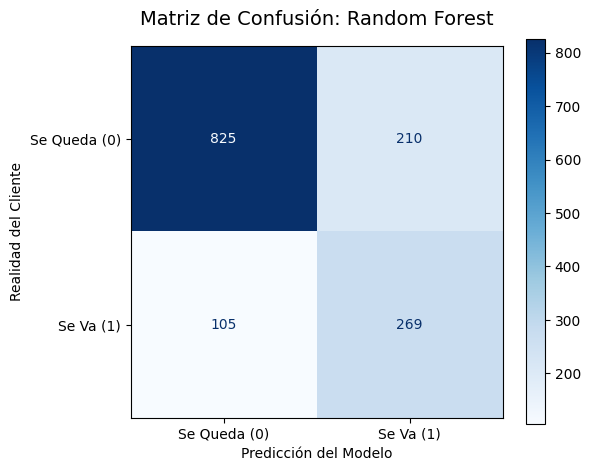

📊 RESULTADOS DEL MODELO: REGRESIÓN LOGÍSTICA 📊
---------------------------------------------
Exactitud (Accuracy) : 0.7388 -> (% de aciertos totales)
Precisión (Precision): 0.5052 -> (De los que dijimos que se van, ¿cuántos realmente se fueron?)
Recall (Sensibilidad): 0.7834 -> (De todos los que se fueron, ¿a cuántos logramos detectar?)
F1-Score             : 0.6143 -> (El equilibrio entre Precisión y Recall)
---------------------------------------------



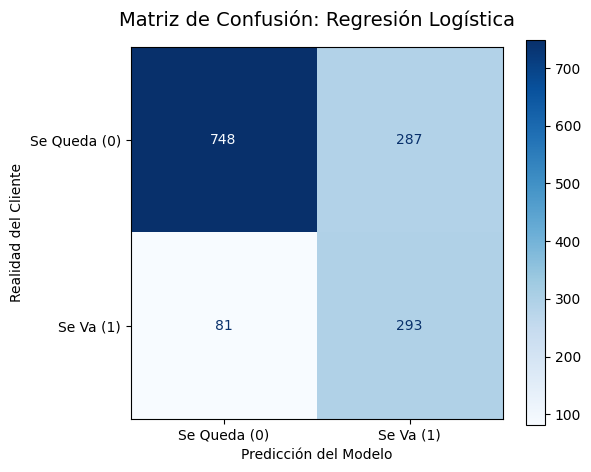

In [154]:
# 1. Traemos los datos frescos (Dataset Original)
X_train, X_test, y_train, y_test, nominales, numericas = preparar_datos_base(df_original)

# 2. Creamos los Preprocesadores
pre_rf = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominales),
    remainder='passthrough'
)

pre_lr = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominales),
    (StandardScaler(), numericas),
    remainder='passthrough'
)

# 3. Armamos los Pipelines Finales
pipeline_rf = Pipeline([
    ('pre', pre_rf),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42))
])

pipeline_lr = Pipeline([
    ('pre', pre_lr),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42))
])

# 4. ENTRENAMOS ambos modelos con el 80% de los datos (X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)

# 5. EVALUACIÓN FINAL: Usamos el 20% que nunca han visto (X_test, y_test)
evaluar_modelo_final(pipeline_rf, X_test, y_test, "Random Forest")
evaluar_modelo_final(pipeline_lr, X_test, y_test, "Regresión Logística")

###Visualizacion de Importancia de las variables

/tmp/ipykernel_374/111208241.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp.head(15), palette='magma')


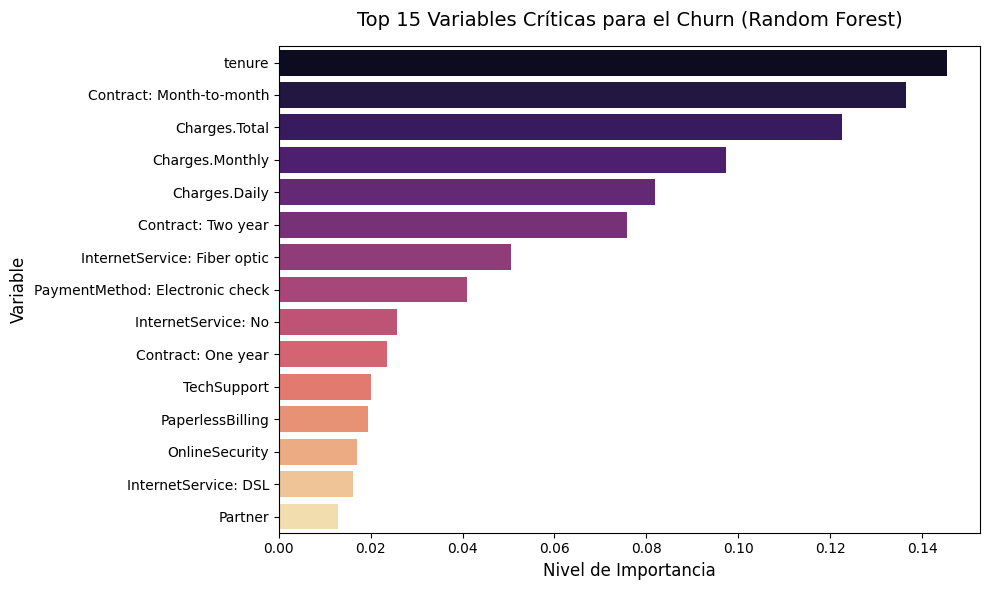

🛑 LAS 10 VARIABLES MENOS IMPORTANTES (Posible 'Ruido'):
-------------------------------------------------------
                                Variable  Importancia
                            OnlineBackup     0.011083
                           SeniorCitizen     0.010792
                           MultipleLines     0.010200
                         StreamingMovies     0.009984
                             StreamingTV     0.009706
PaymentMethod: Bank transfer (automatic)     0.009373
             PaymentMethod: Mailed check     0.008273
                        DeviceProtection     0.008136
  PaymentMethod: Credit card (automatic)     0.007449
                            PhoneService     0.004732


In [155]:
# 1. Extraer los nombres (Random Forest)
nombres_features = pipeline_rf.named_steps['pre'].get_feature_names_out()

# 2. Función de limpieza
def limpiar_nombre_variable(nombre):
    # Primero quitamos los prefijos de scikit-learn (remainder__, onehotencoder__)
    nombre = nombre.split('__')[-1]
    # Si viene del OneHotEncoder, suele tener el formato 'Columna_Valor'
    if '_' in nombre and 'Charges' not in nombre: # Evitamos romper 'Charges_Monthly'
        partes = nombre.split('_', 1) # Separamos solo por el primer '_'
        if len(partes) > 1:
            return f"{partes[0]}: {partes[1]}" # Ej: 'Contract: Month-to-month'
    return nombre

#Aplicamos la funcion a los nombres de las variables de pipeline_rf
nombres_limpios = [limpiar_nombre_variable(n) for n in nombres_features]

# 3. Extraer la importancia que el Random Forest le asignó a cada variable
importancias = pipeline_rf.named_steps['model'].feature_importances_

# 4. Armar un DataFrame y ordenarlo de mayor a menor importancia
df_imp = pd.DataFrame({
    'Variable': nombres_limpios,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 4. Graficar el TOP 15 de variables más influyentes
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_imp.head(15), palette='magma')
plt.title('Top 15 Variables Críticas para el Churn (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Nivel de Importancia', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.show()

# 5. Imprimir las variables MENOS importantes para validar si hay que limpiar el dataset
print("🛑 LAS 10 VARIABLES MENOS IMPORTANTES (Posible 'Ruido'):")
print("-" * 55)
print(df_imp.tail(10).to_string(index=False))

###Optimizacion de la Regresion Logistica

####Feature Selection Manual

In [156]:
# 1. Definimos las variables a eliminar (segun lo observado en el Analisis Dirigido)
variables_a_eliminar = ['gender', 'PhoneService', 'MultipleLines', 'StreamingTV']

# 2. Creamos una versión filtrada del dataset original
df_filtrado = df_original.drop(columns=variables_a_eliminar)

# 3. Actualizamos nuestras listas de columnas para el preprocesador
# Quitamos de las listas nominales aquellas que ya no existen
nuevas_nominales = [col for col in nominales if col not in variables_a_eliminar]
nuevas_numericas = [col for col in numericas if col not in variables_a_eliminar]

# 4. Preparamos los datos con el dataset limpio
X_f = df_filtrado.drop('Churn', axis=1)
y_f = df_filtrado['Churn']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42, stratify=y_f
)

# 5. Re-configuramos el Pipeline para Regresión Logística
pre_lr_manual = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), nuevas_nominales),
    (StandardScaler(), nuevas_numericas),
    remainder='passthrough'
)

pipe_lr_final = Pipeline([
    ('pre', pre_lr_manual),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=5000))
])

# 6. Entrenamos y evaluamos
pipe_lr_final.fit(X_train_f, y_train_f)
y_pred_f = pipe_lr_final.predict(X_test_f)

nuevo_f1_lr_manual = f1_score(y_test_f, y_pred_f)
nuevo_precision_lr_manual = precision_score(y_test_f, y_pred_f)
nuevo_recall_lr_manual = recall_score(y_test_f, y_pred_f)
nueva_exactitud_lr_manual = accuracy_score(y_test_f, y_pred_f)

print(f"🧪 RESULTADOS TRAS ELIMINAR RUIDO (Regresión Logística)")
print("-" * 50)
print(f"F1-Score Anterior : 0.6143")
print(f"F1-Score Nuevo    : {nuevo_f1_lr_manual:.4f}")
print("-" * 50)
print(f"Precisión Anterior: 0.5052")
print(f"Precisión Nueva   : {nuevo_precision_lr_manual:.4f}")
print("-" * 50)
print(f"Recall Anterior   : 0.7834")
print(f"Recall Nuevo      : {nuevo_recall_lr_manual:.4f}")
print("-" * 50)
print(f"Exactitud Anterior   : 0.7388")
print(f"Exactitud Nueva      : {nueva_exactitud_lr_manual:.4f}")

🧪 RESULTADOS TRAS ELIMINAR RUIDO (Regresión Logística)
--------------------------------------------------
F1-Score Anterior : 0.6143
F1-Score Nuevo    : 0.6261
--------------------------------------------------
Precisión Anterior: 0.5052
Precisión Nueva   : 0.5156
--------------------------------------------------
Recall Anterior   : 0.7834
Recall Nuevo      : 0.7968
--------------------------------------------------
Exactitud Anterior   : 0.7388
Exactitud Nueva      : 0.7473


####Feature Selection con RFE

Identificacion de las mejores combinaciones

In [157]:

from sklearn.feature_selection import RFE

# Creamos un objeto unico para el RFE (Dataset completo)
pre_lr_completo = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominales),
    (StandardScaler(), numericas),
    remainder='passthrough'
)

# 1. Obtenemos el número total de variables que salen del preprocesador
# Entrenamos temporalmente el preprocesador para saber cuántas columnas genera el OneHot
pre_lr_completo.fit(X_train)
total_variables = len(pre_lr_completo.get_feature_names_out())

print(f"Iniciando búsqueda sobre {total_variables} variables posibles\n")

resultados_busqueda = []

# 2. El bucle: prueba desde 1 hasta todas las variables
for n in range(1, total_variables + 1):
    rfe_selector = RFE(
        estimator=LogisticRegression(max_iter=5000, random_state=42),
        n_features_to_select=n,
        step=1
    )

    pipe_prueba = Pipeline([
        ('pre', pre_lr_completo),
        ('selector', rfe_selector),
        ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=5000))
    ])

    # Entrenar y predecir
    pipe_prueba.fit(X_train, y_train)
    y_pred_prueba = pipe_prueba.predict(X_test)

    # Guardar métricas
    recall_actual = recall_score(y_test, y_pred_prueba)
    f1_actual = f1_score(y_test, y_pred_prueba)

    resultados_busqueda.append({
        'N_Variables': n,
        'Recall': round(recall_actual, 4),
        'F1-Score': round(f1_actual, 4)
    })

# 3. Convertimos a DataFrame para filtrar fácilmente
df_busqueda = pd.DataFrame(resultados_busqueda)

# 4. Aplicamos las reglas:
# F1 > 0.60 y Recall > 0.75
mejores_configuraciones = df_busqueda[
    (df_busqueda['F1-Score'] > 0.60) &
    (df_busqueda['Recall'] > 0.75)
].sort_values(by='Recall', ascending=False) # Ordenamos por el mejor Recall

print("🔥 LAS MEJORES COMBINACIONES ENCONTRADAS POR LA MÁQUINA:")
print("-" * 55)
if mejores_configuraciones.empty:
    print("Ninguna configuración alcanzó los umbrales mínimos solicitados.")
else:
    print(mejores_configuraciones.to_string(index=False))

Iniciando búsqueda sobre 27 variables posibles

🔥 LAS MEJORES COMBINACIONES ENCONTRADAS POR LA MÁQUINA:
-------------------------------------------------------
 N_Variables  Recall  F1-Score
           6  0.7968    0.6138
          13  0.7941    0.6143
           5  0.7914    0.6072
          12  0.7914    0.6116
          22  0.7888    0.6165
          10  0.7861    0.6151
           8  0.7861    0.6138
          20  0.7861    0.6144
          17  0.7861    0.6125
          19  0.7861    0.6151
           7  0.7834    0.6130
          11  0.7834    0.6123
           9  0.7834    0.6098
          18  0.7834    0.6111
          14  0.7834    0.6149
          21  0.7834    0.6149
          27  0.7834    0.6143
          23  0.7807    0.6096
          15  0.7807    0.6109
          25  0.7807    0.6122
          24  0.7807    0.6115
          26  0.7807    0.6122
          16  0.7781    0.6082


Aplicacion de la mejor combinacion

In [158]:
# Configuramos el RFE específicamente para las 6 variables ganadoras
rfe_top6 = RFE(
    estimator=LogisticRegression(max_iter=5000, random_state=42),
    n_features_to_select=6,
    step=1
)

pipe_top6 = Pipeline([
    ('pre', pre_lr_completo),
    ('selector', rfe_top6),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])

# Entrenamos con todas las variables y dejamos que filtre las 6 mejores
pipe_top6.fit(X_train, y_train)
y_pred_rfe = pipe_top6.predict(X_test)

nuevo_f1_lr_rfe = f1_score(y_test, y_pred_rfe)
nueva_precision_lr_rfe = precision_score(y_test, y_pred_rfe)
nuevo_recall_lr_rfe = recall_score(y_test, y_pred_rfe)
nueva_exactitud_lr_rfe = accuracy_score(y_test, y_pred_rfe)

print(f"🧪 RESULTADOS CON SELECCIÓN AUTOMÁTICA (RFE - CORREGIDO)")
print("-" * 50)
print(f"F1-Score (Manual) : {nuevo_f1_lr_manual:.4f}")
print(f"F1-Score (RFE)    : {nuevo_f1_lr_rfe:.4f}")
print("-" * 50)
print(f"Precisión (Manual): {nuevo_precision_lr_manual:.4f}")
print(f"Precisión (RFE)   : {nueva_precision_lr_rfe:.4f}")
print("-" * 50)
print(f"Recall (Manual)   : {nuevo_recall_lr_manual:.4f}")
print(f"Recall (RFE)      : {nuevo_recall_lr_rfe:.4f}")
print("-" * 50)
print(f"Exactitud (Manual): {nueva_exactitud_lr_manual:.4f}")
print(f"Exactitud (RFE)   : {nueva_exactitud_lr_rfe:.4f}")

# Extraemos los nombres
nombres_tras_pre = pipe_top6.named_steps['pre'].get_feature_names_out()
variables_top6 = nombres_tras_pre[pipe_top6.named_steps['selector'].support_]

print("💎 LAS 6 VARIABLES MÁS CRÍTICAS SEGÚN LA MÁQUINA:")
print("-" * 50)
for v in variables_top6:
    print(f" - {v.split('__')[-1]}")

🧪 RESULTADOS CON SELECCIÓN AUTOMÁTICA (RFE - CORREGIDO)
--------------------------------------------------
F1-Score (Manual) : 0.6261
F1-Score (RFE)    : 0.6138
--------------------------------------------------
Precisión (Manual): 0.5156
Precisión (RFE)   : 0.4992
--------------------------------------------------
Recall (Manual)   : 0.7968
Recall (RFE)      : 0.7968
--------------------------------------------------
Exactitud (Manual): 0.7473
Exactitud (RFE)   : 0.7339
💎 LAS 6 VARIABLES MÁS CRÍTICAS SEGÚN LA MÁQUINA:
--------------------------------------------------
 - Contract_Month-to-month
 - Contract_Two year
 - tenure
 - Charges.Monthly
 - PhoneService
 - TechSupport


###Umbral de Precision

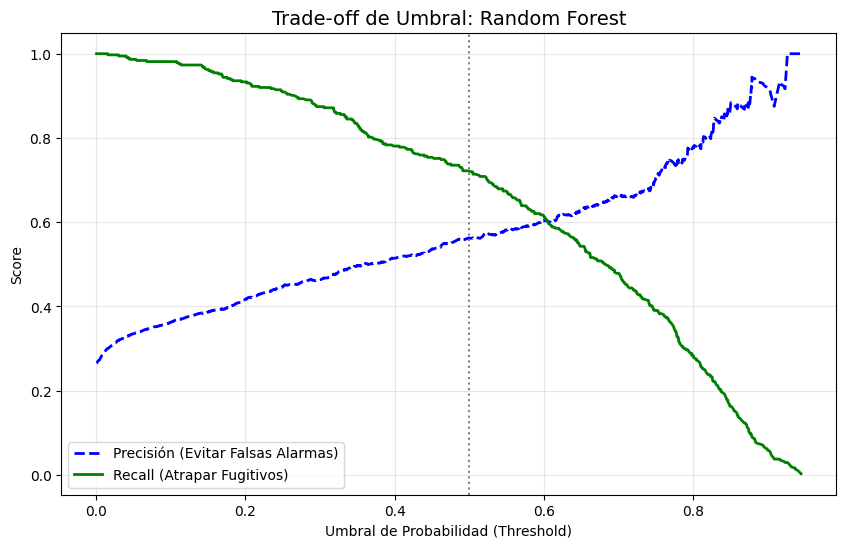

🎯 Para el modelo Random Forest:
El umbral que mejor equilibra ambos mundos es: 0.49
Con ese umbral lograrías -> F1: 0.6358


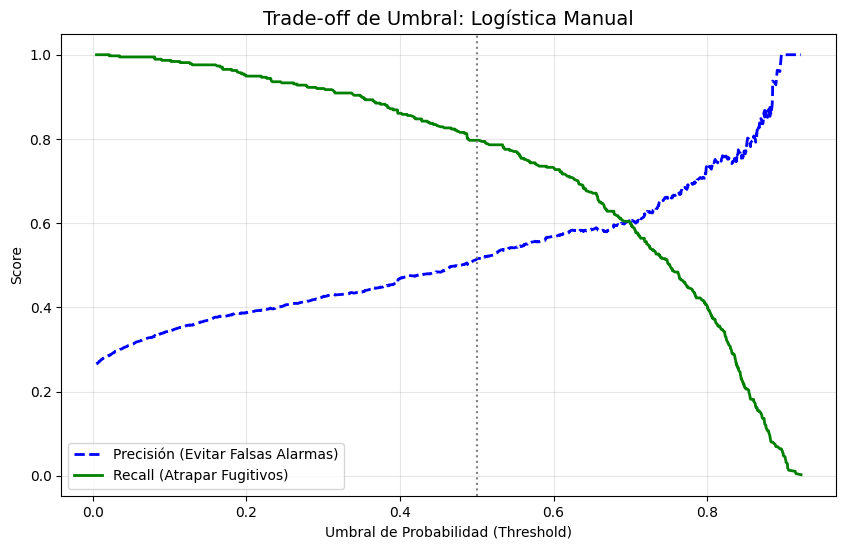

🎯 Para el modelo Logística Manual:
El umbral que mejor equilibra ambos mundos es: 0.60
Con ese umbral lograrías -> F1: 0.6409


In [159]:
from sklearn.metrics import precision_recall_curve

def buscar_umbral_optimo(modelo, X_test, y_test, nombre):
    # 1. Obtenemos las probabilidades (no las clases 0/1)
    probs = modelo.predict_proba(X_test)[:, 1]

    # 2. Calculamos precisiones y recalls para cientos de umbrales distintos
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

    # 3. Graficamos la relación
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precisión (Evitar Falsas Alarmas)', lw=2)
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Atrapar Fugitivos)', lw=2)

    # Dibujamos una línea donde se cruzan (Equilibrio)
    plt.axvline(x=0.5, color='gray', linestyle=':')
    plt.title(f'Trade-off de Umbral: {nombre}', fontsize=14)
    plt.xlabel('Umbral de Probabilidad (Threshold)')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 4. Encontrar el umbral que maximiza el F1-Score automáticamente
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    idx_optimo = np.argmax(f1_scores)
    umbral_optimo = thresholds[idx_optimo]

    print(f"🎯 Para el modelo {nombre}:")
    print(f"El umbral que mejor equilibra ambos mundos es: {umbral_optimo:.2f}")
    print(f"Con ese umbral lograrías -> F1: {f1_scores[idx_optimo]:.4f}")

# Ejecutamos para ambos modelos
buscar_umbral_optimo(pipeline_rf, X_test, y_test, "Random Forest")
buscar_umbral_optimo(pipe_lr_final, X_test_f, y_test_f, "Logística Manual")

Aplicacion de los umbrales obtenidos

In [160]:
# 1. Predicciones para Logística (Umbral 0.60)
probs_lr = pipe_lr_final.predict_proba(X_test_f)[:, 1]
preds_lr = (probs_lr >= 0.60).astype(int)

# 2. Predicciones para Random Forest (Umbral 0.49)
probs_rf = pipeline_rf.predict_proba(X_test)[:, 1]
preds_rf = (probs_rf >= 0.49).astype(int)

# 3. Función para extraer métricas de negocio
def extraer_metricas(y_real, y_pred, nombre):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    return {
        'Modelo': nombre,
        'F1-Score': f1_score(y_real, y_pred),
        'Precision (Eficiencia)': precision_score(y_real, y_pred),
        'Recall (Captura)': recall_score(y_real, y_pred),
        'Exactitud': accuracy_score(y_real, y_pred),
        'Falsas Alarmas (FP)': fp,  # Dinero desperdiciado
        'Fugas no detectadas (FN)': fn # Clientes perdidos
    }

# 4. Creamos la tabla comparativa
df_comparativa = pd.DataFrame([
    extraer_metricas(y_test_f, preds_lr, "Logística (U: 0.60)"),
    extraer_metricas(y_test, preds_rf, "Random Forest (U: 0.49)")
])

print("🏆 COMPARATIVA ESTRATÉGICA DE COSTOS")
print("-" * 60)
print(df_comparativa.to_string(index=False))

🏆 COMPARATIVA ESTRATÉGICA DE COSTOS
------------------------------------------------------------
                 Modelo  F1-Score  Precision (Eficiencia)  Recall (Captura)  Exactitud  Falsas Alarmas (FP)  Fugas no detectadas (FN)
    Logística (U: 0.60)  0.639344                0.568750          0.729947   0.781405                  207                       101
Random Forest (U: 0.49)  0.631823                0.558522          0.727273   0.775018                  215                       102


###Serializacion

In [161]:
import joblib

# 1. Definimos una pequeña clase para empaquetar todo
class ModeloRetencion:
    def __init__(self, pipeline, threshold):
        self.pipeline = pipeline
        self.threshold = threshold

    def predict(self, X):
        # Usamos predict_proba y aplicamos el umbral
        probs = self.pipeline.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# 2. Creamos la instancia con el modelo ganador (Regresion Logistica) y el umbral 0.60
modelo_final = ModeloRetencion(pipe_lr_final, threshold=0.60)

# 3. Serializamos
joblib.dump(modelo_final, 'modelo_retencion_final.pkl')

print("✅ El modelo campeón ha sido serializado exitosamente como 'modelo_retencion_final.pkl'")

✅ El modelo campeón ha sido serializado exitosamente como 'modelo_retencion_final.pkl'


Prueba de la serializacion realizada:

In [162]:
# 1. Cargamos el modelo que acabamos de guardar
modelo_cargado = joblib.load('modelo_retencion_final.pkl')

# 2. Generamos predicciones con el modelo ORIGINAL (memoria)
# Aplicamos el umbral manualmente
probs_original = pipe_lr_final.predict_proba(X_test_f)[:, 1]
preds_original = (probs_original >= 0.60).astype(int)

# 3. Generamos predicciones con el modelo CARGADO (archivo)
# El 'Wrapper' ya tiene el umbral 0.60 por dentro
preds_cargado = modelo_cargado.predict(X_test_f)

# 4. Comparación de consistencia
son_identicos = np.array_equal(preds_original, preds_cargado)
diferencias = np.sum(preds_original != preds_cargado)

print("🧪 PRUEBA DE INTEGRIDAD DEL MODELO")
print("-" * 40)
if son_identicos:
    print("✅ ¡ÉXITO! El modelo serializado es 100% consistente con el original.")
    print(f"   Umbral verificado: {modelo_cargado.threshold}")
else:
    print(f"❌ ATENCIÓN: Se encontraron {diferencias} discrepancias entre los modelos.")

# 5. Verificación de una muestra aleatoria
print(f"\nMuestra de predicciones (Primeras 10):")
print(f"Original: {preds_original[:10]}")
print(f"Cargado:  {preds_cargado[:10]}")

🧪 PRUEBA DE INTEGRIDAD DEL MODELO
----------------------------------------
✅ ¡ÉXITO! El modelo serializado es 100% consistente con el original.
   Umbral verificado: 0.6

Muestra de predicciones (Primeras 10):
Original: [0 1 1 0 0 0 0 0 0 1]
Cargado:  [0 1 1 0 0 0 0 0 0 1]


#**📊 Informe Técnico y Estratégico: Predicción de Fuga de Clientes (Churn)**

##**Índice**  
1. [Introducción y Objetivo](#introducción-y-objetivo)  
2. [Comparativa de Modelos y Optimización](#comparativa-optimizacion)  
3. [Rendimiento y Evolución de los Modelos](#rendimiento-evolucion)  
4. [Conclusión de Selección](#conclusion-seleccion)
5. [Estrategia de Retención Inteligente](#estrategia-de-retencion)  
6. [Los Hallazgos](#hallazgos)
7. [Propuestas Estratégicas](#propuestas)
8. [Conclusión de Implementación](#conclusion-implementacion)

<br>

<a name="introducción-y-objetivo"></a>
##**1. Introducción y Objetivo Estratégico**

Este proyecto desarrolla un sistema de Inteligencia Artificial enfocado en predecir y entender la fuga de clientes (Churn). El objetivo principal es dotar a la empresa de una herramienta que no solo identifique "quién" está en riesgo de irse, sino "por qué", permitiendo transicionar de un modelo reactivo a una estrategia de retención proactiva y personalizada.

<br>

<a name="comparativa-optimizacion"></a>
##**2. Comparativa de Modelos y Optimización**
Para encontrar el motor predictivo ideal, evaluamos múltiples configuraciones utilizando técnicas de balanceo de clases para asegurar la detección efectiva de la minoría (los clientes que cancelan).

Modelo / Iteración | Exactitud| F1-Score | Precisión | Recall
----|---- |-----  |----- |-----
Random Forest (Base)| 77.64% | 0.6307 | 56.16% | 71.93%
Random Forest (Umbral)| 77.50% | 0.6318 | 55.85% | 72.72%
Regresión Logística (Base)| 73.88% | 0.6143 | 50.52% | 78.34%
Regresión Logística (Auto RFE)| 73.39% | 0.6138 | 49.92% | 79.68%
Regresión Logística (Manual)| 74.73% | 0.6261 | 51.56% | 79.68%
Regresion Logistica (Umbral)| 78.14% | 0.6393 | 56.87%  | 72.99%

<br>

<a name="rendimiento-evolucion"></a>
##**3. Rendimiento y Evolución de los Modelos**
Para encontrar la solución óptima, no solo entrenamos algoritmos, sino que los sometimos a un proceso de refinamiento en tres etapas: **Línea Base**, **Ingeniería de Variables** y **Ajuste Estratégico de Umbrales**.

<br>

###**3.1. Punto de Partida: Modelos Base**
En la primera iteración, comparamos las versiones estándar de ambos algoritmos (usando un umbral por defecto de 0.50):

**Random Forest (Base):** Demostró ser el modelo más "equilibrado" desde el inicio, con una Exactitud del **77.64%** y la mejor capacidad para evitar falsas alarmas (Precisión: **56.16%**).

**Regresión Logística (Base):** Se comportó como un "vigilante agresivo". Aunque su **exactitud fue menor**, su capacidad para detectar clientes en riesgo (Recall: **78.34%**) superó naturalmente al Random Forest, aunque a costa de señalar a muchos clientes que no pensaban irse.

<br>

###**3.2. Regresión Logística: Automatización vs. Inteligencia de Negocio**
Durante la optimización de la Regresión Logística, enfrentamos un algoritmo de **selección automática (RFE)** contra una **limpieza manual** basada en el Análisis Dirigido (eliminando variables de "ruido" como gender, PhoneService y StreamingTV).

**El hallazgo:** La intuición humana superó a la máquina. Al limpiar el ruido manualmente, logramos **aumentar la Precisión y el Recall** simultáneamente. Mientras que el **RFE coincidió en el Recall**, obtuvo porcentajes menores en el resto de las métricas. El modelo optimizado manualmente demostró ser capaz de atrapar a **8 de cada 10 clientes** en riesgo, manteniendo una base sólida de datos limpios.

> **Nota de Validación:** Es fundamental destacar que, aunque la limpieza manual obtuvo métricas superiores, el algoritmo **RFE** cumplió una función de validación crítica: confirmó que el modelo **alcanza su máximo potencial con apenas 6 variables clave**.
 Esto demuestra que el fenómeno de la fuga en nuestra compañía no es un "ruido caótico", sino que responde a **patrones** muy específicos y detectables (como el tipo de contrato y el método de pago).
 Aun asi, se prefiere a limpieza manual ya que permitió integrar el **conocimiento del negocio**.

<br>

###**3.3. El Salto Final: Ajuste de Umbrales (Optimización de Costos)**
La mejora definitiva llegó al ajustar los **umbrales de decisión** para mover el "dial" entre precisión y sensibilidad:

**Random Forest (Umbral 0.49):** Logró una mejora marginal en el F1-Score, pero se mantuvo por debajo de la potencia de la Logística.

**Regresión Logística (Umbral 0.60):** Este ajuste fue el "punto de inflexión" del proyecto. Al elevar el umbral a 0.60, logramos:

 *  **Máxima Eficiencia:** Alcanzar la Exactitud más alta de todo el estudio (78.14%).

 *  **Equilibrio Perfecto:** El mejor F1-Score (0.6393), superando incluso la precisión natural del Random Forest (56.87%).

<br>

<a name="conclusion-seleccion"></a>
###**Conclusión de Selección**
Aunque el Random Forest es un modelo potente, la **Regresión Logística con Umbral 0.60 se corona como la herramienta ganadora**. Es el modelo más inteligente para el negocio: es el que menos se equivoca al señalar desertores y el que mejor balancea el costo de perder un cliente frente al costo de una campaña de retención.

<br>

<a name="estrategia-de-retencion"></a>
##**Estrategia de Retención Inteligente: Hacia un Crecimiento Sostenible**

<a name="hallazgos"></a>
###**1. Los Hallazgos: El ADN de la Fuga**
Tras auditar el comportamiento de los desertores mediante técnicas de Machine Learning y análisis estadístico dirigido, hemos identificado los **6 factores críticos** que disparan la salida de clientes:

 * **Sensibilidad al Precio (Cargos Altos):** El análisis de densidad (KDEPlot) confirma una correlación directa: **quienes más pagan, más se van**. Los clientes fugados presentan cargos mensuales significativamente más altos, lo que sugiere que el servicio se percibe como un "gasto" pesado y no como una **inversión de valor**.

 * **Vulnerabilidad del Contrato "Mes a Mes":** Este es el predictor más fuerte de abandono. El riesgo máximo ocurre en el "Valle de la Muerte" (meses 6 a 10). Sin embargo, este riesgo se desploma casi a cero en clientes con contratos de 1 o 2 años; la **permanencia legal** es el mejor antídoto contra el churn.

 * **La Paradoja de la Fibra Óptica:** A pesar de ser nuestro producto estrella, los clientes de Fibra son los más propensos a la fuga. Esto indica un **desajuste crítico** entre el costo premium del servicio y la calidad percibida o la competitividad del precio frente al mercado.

 * **Fricción del Paperless Billing (33.6% Churn):** La digitalización está **fallando**. La alta tasa de fuga en este segmento sugiere que la factura digital está rompiendo el vínculo informativo con el cliente o generando frustración en su recepción.

 * **El "Dolor" del Pago Manual:** El uso de Electronic Check obliga al cliente a realizar una acción consciente de pago cada mes, dándole la oportunidad de cuestionar la continuidad del servicio. Los **métodos automáticos** "invisibilizan" el gasto y garantizan mayor **lealtad**.

 * **Servicios "Ancla" Ausentes:** La falta de Online Security y Tech Support **duplica el riesgo**. Sin estos servicios, el internet se convierte en un commodity genérico y fácil de reemplazar por la competencia.

<br>

<a name="propuestas"></a>
###**2. Propuestas Estratégicas: El "Telco Playbook"**
Basándonos en las mejores prácticas de la industria de telecomunicaciones, proponemos **cinco líneas de acción** diseñadas para intercambiar valor por lealtad:

####**Estrategia 1: Auditoría de Valor "Fibra 360" (Producto)**
 * **Acción:** Ejecutar un monitoreo técnico proactivo en usuarios de Fibra Óptica y realizar un Benchmark de precios regional.

 * **Propuesta:** Si el modelo detecta un cliente de alto valor en una zona competitiva, disparar un **"Ajuste de Plan Proactivo"** (ej. aumentar velocidad al mismo precio) antes de que el cliente considere la competencia.

####**Estrategia 2: Programa "Puente de Lealtad" (Fidelización)**
 * **Acción:** Intervención automatizada en el mes 8 para clientes con contrato "Mes a Mes".

 * **Propuesta:** Ofrecer el salto a contrato anual a cambio de un **"Upgrade de Beneficios"** (ej. más datos o servicios gratuitos) que no represente un costo operativo alto para la empresa, pero sí un alto valor percibido para el usuario.

####**Estrategia 3: Ecosistema "Tranquilidad Total" (Servicios Ancla)**
 * **Acción:** Crear un bundle que incluya Online Security y Tech Support de forma gratuita.

 * **Propuesta:** Este beneficio se otorga únicamente a cambio de una extensión de **contrato a 24 meses**. El objetivo es transformar el servicio en una herramienta de seguridad familiar difícil de abandonar.

####**Estrategia 4: Incentivo "Click & Forget" (Financiera)**
 * **Acción:** Desincentivar el uso de Electronic Check.

 * **Propuesta:** Ofrecer un **descuento mensual pequeño** (ej. 3%) a todo cliente que active el **Pago Automático** y mantenga la factura digital. El ahorro en costos de cobranza y la reducción de la "decisión de pago" mensual compensan sobradamente el descuento.

####**Estrategia 5: Plan "Hogar Conectado" (Anclaje Social)**
 * **Acción:** Incentivar la adición de familiares o dependientes a la cuenta principal.

 * **Propuesta:** Ofrecer **licencias de seguridad móvil** para familiares con descuento. Cuantos más miembros de la casa dependan de los beneficios del titular, mayor es el costo psicológico y logístico de cancelar el servicio.

<br>

<a name="conclusion-implementacion"></a>
###**3. Conclusión de Implementación**
Para que estas estrategias sean rentables, se utilizará el modelo de **Regresión Logística (Umbral 0.60)** como motor de disparo. Esto asegura que los recursos de retención (descuentos y beneficios) se dirijan quirúrgicamente al **73% de los desertores potenciales**, minimizando el desperdicio en clientes que no presentan riesgo de fuga.